### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


In [4]:
import pandas as pd

df = pd.read_csv("grades_crpt.csv")

# Basic information
print(df.head())
print(df.info())
print(df.describe())

      A1    A2    A3    A4     A5     A6    A7  Final_Exam user_id
0    NaN   NaN  30.0  75.0   90.0   65.0  50.6        68.8    U001
1  100.0   NaN   NaN  92.5  100.0  100.0  84.4        50.3    U002
2   75.0  69.6   NaN  86.2  100.0    NaN   NaN        67.8    U003
3   25.0  78.6  40.0   0.0   50.0   30.7   0.0         0.0    U004
4    0.0   NaN   0.0   0.0    NaN    NaN   NaN         0.0    U005
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6

Dataset contains grades for 7 assignments from a1-a7 and the final exam. There are lots of missing  throughout. Some of the grades are negative.
Some grades are also higher than 100

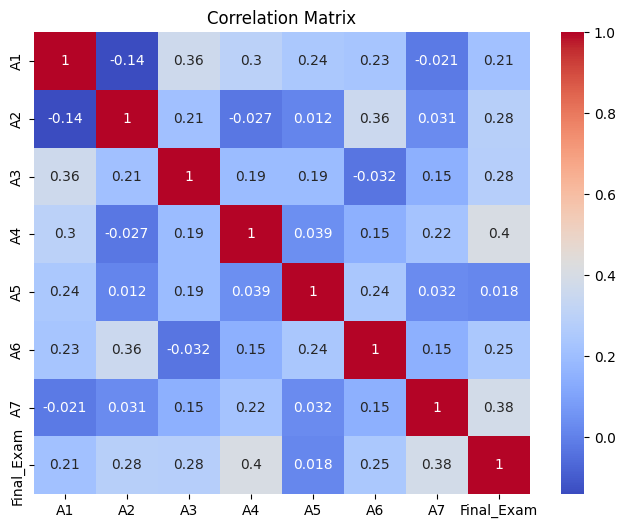

In [5]:
#Correlation

import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.drop(columns=["user_id"]).corr() #removes the user ID column

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm") #annot=True prints the actual values in the cells so you can see them
plt.title("Correlation Matrix")
plt.show()

In [6]:
#Correlation with Final Exam
corr_with_final = corr_matrix["Final_Exam"].sort_values(ascending=False) #only takes the final exam column scores and sorts them high to low
print(corr_with_final)

Final_Exam    1.000000
A4            0.403466
A7            0.380756
A2            0.284525
A3            0.277859
A6            0.246127
A1            0.212839
A5            0.018271
Name: Final_Exam, dtype: float64


Strongest correlations with the final exam are A4 with 0.40 and A7 with 0.37. So, if only two assignments could be used those would be the best as they have the highest correlation to the final exam and would most likely provide the best performance.



In [7]:
# Missing Values
print(df.isnull().sum())

A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64


A1 has the most missing values of any assignment. Final exam and users dont have any missing.

In [8]:
# Compare Imputation

#1 Mean
mean_df = df.copy() #makes a copy so actual results aren't changed

for col in ["A1","A2","A3","A4","A5","A6","A7"]:
    mean_df[col] = mean_df[col].fillna(mean_df[col].mean()) #finds and fills any missing values

#2 Median
median_df = df.copy()

for col in ["A1","A2","A3","A4","A5","A6","A7"]:
    median_df[col] = median_df[col].fillna(median_df[col].median())

#3 Remove Missing

drop_df = df.dropna()

In [9]:
# Comparison

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()
#Loop through the data
for name, data in [("Mean", mean_df), ("Median", median_df), ("Drop", drop_df)]:
    X = data[["A4", "A7"]] # inputs assignemnts scores
    y = data["Final_Exam"] # outputs exams scores
    print(name, cross_val_score(model, X, y, cv=5, scoring="r2").mean())

Mean 0.030065604565230997
Median 0.03519113717313686
Drop -7.091233447593426


Median worked the best with the highest score of 0.035. Meidan is less affected by the extreme ends of values that are in the dataset. Mean was a bit worse because outliers like really high or low grades can change the average up/down depending. Removing rows was not good at all as it lowered the number of the set whihc made the model lose quite a bit of info and made it perform poorly.

Exploration Idea: We coulkd compare different missing value strategies by looking at how they affect the results. A method would work better if it keeps more of the useful usable data and can keep the original patterns in the dataset so it doesnt mess with anything negatviely which can lead to more accurate predictions when trying to do so. Comparing the models performance after changing each strategy is a good way to find out which one works best.

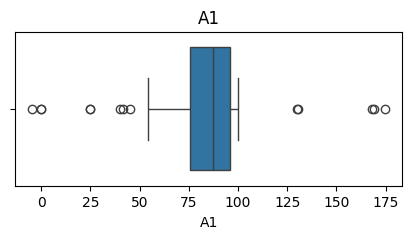

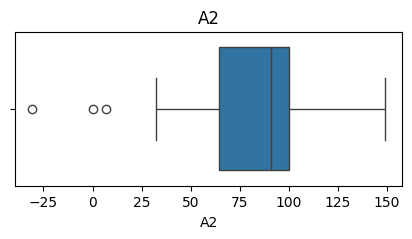

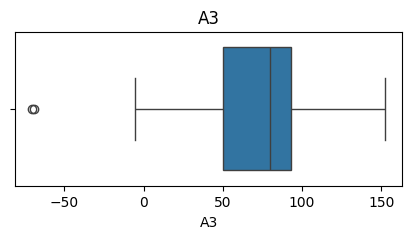

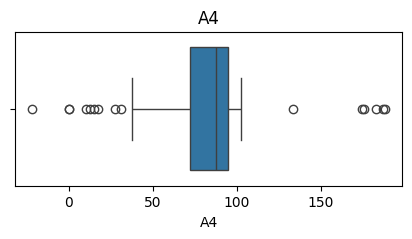

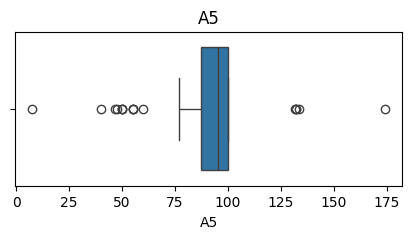

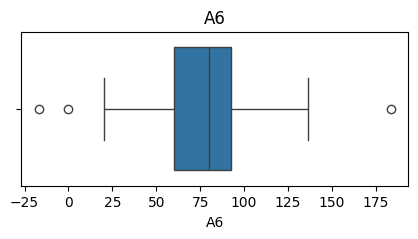

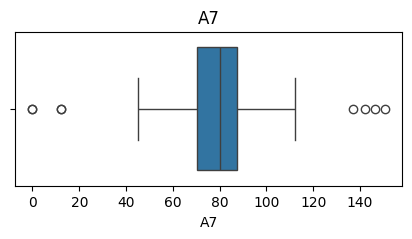

In [10]:
#Check for outliers
assignments = ["A1","A2","A3","A4","A5","A6","A7"]

for col in assignments:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Unrealistic/Suspicious values: some grades were negative in the assignemnts such as in A2 where there was roughly a -30, A3: -70, etc. and then there were also extremely high grades like A1: around 175, A4: around 180 etc. These are unrealistic because even if you add bonus marks they're still much to high.

I believe the best approach to the outliers would be to modify them. For example, if a value is below zero, then it would just be a 0, and if a score is above the maxixmum possible score it will default to the maximum score which is possible. So, you can apply limits to each assigntment depending on the limit and go from there. I think this would be the best approach as it doesn't totally negate the scores that people achieve but makes them more tangible and relaistic to include and won't skew the results as much as other methods. Also, if you keep the outlier results the results are more unrealistic as well as the scores are not actually acheivable in a real scenario.